In [109]:
from palmerpenguins import load_penguins
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


data = load_penguins()

In [110]:
filename = "https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/palmer_penguins_openclassrooms.csv"
data = pd.read_csv(filename)

In [111]:
data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Chinstrap,Dream,40.9,16.6,187.0,3200.0,female,2008
1,Adelie,Dream,36.5,18.0,182.0,3150.0,female,2007
2,Chinstrap,Dream,46.5,17.9,192.0,3500.0,female,2007
3,Gentoo,Biscoe,54.3,15.7,231.0,5650.0,male,2008
4,Gentoo,Biscoe,46.3,15.8,215.0,5050.0,male,2007
...,...,...,...,...,...,...,...,...
328,Chinstrap,Dream,52.0,19.0,197.0,4150.0,male,2007
329,Adelie,Dream,37.3,17.8,191.0,3350.0,female,2008
330,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
331,Chinstrap,Dream,46.4,18.6,190.0,3450.0,female,2007


In [112]:
reg = LinearRegression()
X = data['bill_length_mm'].values.reshape(-1, 1)
y = data['body_mass_g']
reg.fit(X, y)
print(reg.score(X,y))

0.3474526112888374


In [113]:
reg = LinearRegression()
X = data[['bill_depth_mm', 'bill_length_mm']].values.reshape(-1, 2)
y = data['body_mass_g']
reg.fit(X, y)
print(reg.score(X,y))

0.4674645243092971


In [114]:
reg = LinearRegression()
X = data['flipper_length_mm'].values.reshape(-1, 1)
y = data['body_mass_g']
reg.fit(X, y)
print(reg.score(X,y))

0.7620921573403914


In [115]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
scaler = MinMaxScaler()
X = scaler.fit_transform(data[['bill_length_mm','bill_depth_mm','flipper_length_mm']])
reg = LinearRegression()
y = data['body_mass_g']

reg.fit(X, y)
y_pred_test = reg.predict(X)
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
print(f"RMSE: {mean_squared_error(y, y_pred_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y, y_pred_test)}")

RMSE: 152597.33274339672
MAPE: 0.07718264712272083


In [116]:
scaler = MinMaxScaler()
reg = LinearRegression()
for espece in ['Adelie', 'Gentoo', 'Chinstrap']:
    df = data[data.species == espece].copy()
    y = df['body_mass_g']
    X = scaler.fit_transform(df[['bill_length_mm','bill_depth_mm','flipper_length_mm']])
    reg.fit(X, y)
    print("--\n",espece, reg.score(X, y))

    y_pred = reg.predict(X)
    print(f"RMSE: {mean_squared_error(y, y_pred)}")
    print(f"MAPE: {mean_absolute_percentage_error(y, y_pred)}")


--
 Adelie 0.5064249444393831
RMSE: 103103.77927187756
MAPE: 0.0688582880470465
--
 Gentoo 0.6280736371428204
RMSE: 92745.44334404985
MAPE: 0.04719861757681761
--
 Chinstrap 0.50381439825875
RMSE: 72215.44695584575
MAPE: 0.056609766769789266


In [117]:
scaler = MinMaxScaler()
y = data['body_mass_g']
X = scaler.fit_transform(data[['bill_length_mm','bill_depth_mm','flipper_length_mm']])
reg = LinearRegression()

In [118]:
from tqdm import tqdm

scores = []
train_test_ratio = [0.2, 0.4, 0.6, 0.8]
random_seeds = [n for n  in  range(0,200,1)]

for ratio in tqdm(train_test_ratio):       
    for seed in random_seeds:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ratio, random_state=seed)
        
        reg.fit(X_train, y_train)
        # Prediction sur le test set
        y_pred_test = reg.predict(X_test)

        scores.append({
            'ratio': ratio,
            'seed': seed, 
            'rmse': mean_squared_error(y_test, y_pred_test)
        })
scores = pd.DataFrame(scores)


100%|██████████| 4/4 [00:01<00:00,  2.85it/s]


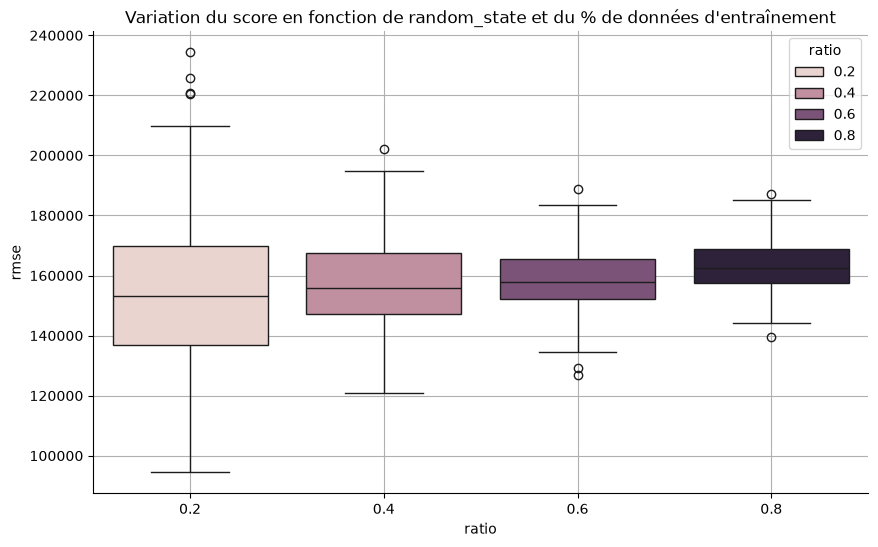

In [119]:
fig = plt.figure(figsize=(10, 6))
sns.boxplot(x = 'ratio', y = 'rmse', hue = 'ratio', data = scores )
sns.despine()
plt.title("Variation du score en fonction de random_state et du % de données d'entraînement")
plt.grid()

In [120]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

filename = "https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/palmer_penguins.csv"
data = pd.read_csv(filename)

In [121]:
dict = {'male' : 0, 'female' : 1}
data['sex'] = data['sex'].map(dict)
data.dropna(inplace=True)
data['sex'] = data.sex.astype('int')

data['sex'].value_counts()

sex
0    168
1    165
Name: count, dtype: int64

In [122]:
scaler = MinMaxScaler()
y = data['sex'].values
X = scaler.fit_transform(data[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

clf = LogisticRegression(random_state = 42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)
confusion_matrix(y_test, y_pred)

array([[28,  3],
       [ 6, 30]])

In [142]:
y_proba

array([0.87619045, 0.43814818, 0.30439436, 0.65380578, 0.4450401 ,
       0.04773485, 0.25217277, 0.17424522, 0.10097369, 0.75095621,
       0.31696567, 0.10654531, 0.75618906, 0.60728291, 0.56832139,
       0.87097435, 0.85453537, 0.83788575, 0.51088288, 0.49333097,
       0.38236647, 0.7178472 , 0.75953125, 0.58020046, 0.69907105,
       0.88262402, 0.61386947, 0.26589857, 0.12303958, 0.1265016 ,
       0.71182972, 0.3817552 , 0.17414092, 0.63736315, 0.27832704,
       0.22776582, 0.14818035, 0.38273196, 0.73437407, 0.93973994,
       0.59180152, 0.72327869, 0.28610187, 0.72928664, 0.60121183,
       0.87958405, 0.17487365, 0.3123746 , 0.28082292, 0.10022287,
       0.66110682, 0.06406536, 0.70803395, 0.60178675, 0.1879618 ,
       0.20479011, 0.78538876, 0.07999012, 0.10128708, 0.39998389,
       0.81690823, 0.2054867 , 0.14459246, 0.50319138, 0.31012965,
       0.55607035, 0.88401422])

In [123]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

In [143]:
print(f"tn : {tn}\nfp : {fp}\nfn : {fn}\ntp : {tp}")

tn : 28
fp : 3
fn : 6
tp : 30


In [125]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_test, y_pred)

0.9090909090909091

In [126]:
recall_score(y_test, y_pred)

0.8333333333333334

In [127]:
y_proba = clf.predict_proba(X_test)[:,1]
y_pred_03 = [ 0 if value < 0.3 else 1 for value in y_proba ]
y_pred_07 = [ 0 if value < 0.7 else 1 for value in y_proba ]


In [128]:
confusion_matrix(y_test, y_pred)

array([[28,  3],
       [ 6, 30]])

In [129]:
confusion_matrix(y_test, y_pred_03)

array([[22,  9],
       [ 1, 35]])

In [130]:
confusion_matrix(y_test, y_pred_07)

array([[30,  1],
       [18, 18]])

In [131]:
data.loc[data.species == 'Adelie', 'species'] = '3'
data.loc[data.species == 'Gentoo', 'species'] = '2'
data.loc[data.species == 'Chinstrap', 'species'] = '1'
data['species'] = data.species.astype('int')

In [132]:
data['species'].value_counts()

species
3    146
2    119
1     68
Name: count, dtype: int64

In [133]:
scaler = MinMaxScaler()
y = data['species'].values

In [134]:
X1 = scaler.fit_transform(data[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']])
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [135]:
X2 = scaler.fit_transform(data[['bill_length_mm','bill_depth_mm','flipper_length_mm']])
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.20, random_state=42)

In [136]:
clf1 = LogisticRegression(random_state = 42)
clf1.fit(X1_train, y1_train)
clf2 = LogisticRegression(random_state = 42)
clf2.fit(X2_train, y2_train)

y1_pred = clf1.predict(X1_test)
y2_pred = clf2.predict(X2_test)


In [137]:
confusion_matrix(y1_test, y1_pred)

array([[16,  0,  2],
       [ 0, 18,  0],
       [ 0,  0, 31]])

In [138]:
confusion_matrix(y2_test, y2_pred)

array([[16,  0,  2],
       [ 0, 18,  0],
       [ 0,  0, 31]])

In [139]:
X = data[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g','sex']]

from sklearn.cluster import KMeans
km = KMeans( n_clusters=3, random_state = 808, n_init = 10)
km.fit(X)
y_pred = km.labels_
data['labels'] = km.labels_


In [140]:
data[['species', 'labels', 'island']].groupby(by = ['species', 'labels']).count().reset_index().rename(columns = {'island': 'count_'})

,species,labels,count_
0,1,0,52
1,1,1,16
2,2,0,1
3,2,1,48
4,2,2,70
5,3,0,108
6,3,1,38


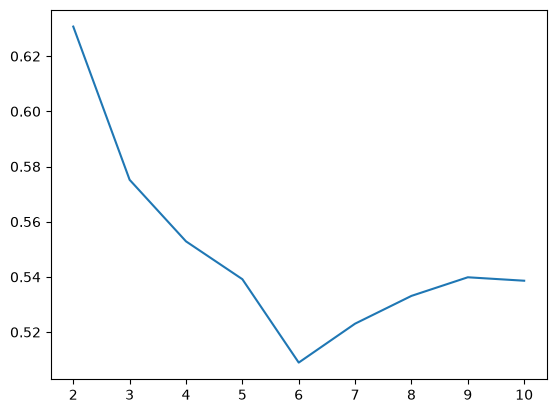

In [141]:
from sklearn.metrics import silhouette_score

scores = []
for n in range(2, 11, 1):
    km = KMeans( n_clusters=n, random_state = 808, n_init = 10)
    km.fit(X)
    labels_ = km.predict(X)
    scores.append(silhouette_score(X,labels_ ))

plt.plot(range(2, 11, 1), scores)
